<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/Intro_to_ML(LogisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salihacur/diabetes")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 6.87MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/salihacur/diabetes/versions/2


In [4]:
import os
print(os.listdir(path))

['diabetes.csv']


In [6]:
df = pd.read_csv(f"{path}/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
feature_cols = ["Pregnancies","Glucose","BloodPressure","Insulin","BMI","Age",
"DiabetesPedigreeFunction"]
x = df[feature_cols]
y = df.Outcome
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  Insulin   BMI  Age  \
0              6      148             72        0  33.6   50   
1              1       85             66        0  26.6   31   
2              8      183             64        0  23.3   32   
3              1       89             66       94  28.1   21   
4              0      137             40      168  43.1   33   
..           ...      ...            ...      ...   ...  ...   
763           10      101             76      180  32.9   63   
764            2      122             70        0  36.8   27   
765            5      121             72      112  26.2   30   
766            1      126             60        0  30.1   47   
767            1       93             70        0  30.4   23   

     DiabetesPedigreeFunction  
0                       0.627  
1                       0.351  
2                       0.672  
3                       0.167  
4                       2.288  
..                        ...  
763    

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(576, 7) (576,) (192, 7) (192,)


In [10]:
model = LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(x_test)
print(y_pred)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0
 0 1 0 0 0 0 0]


In [13]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[118  12]
 [ 26  36]]
0.8020833333333334


<Axes: xlabel='Predicted', ylabel='Actual'>

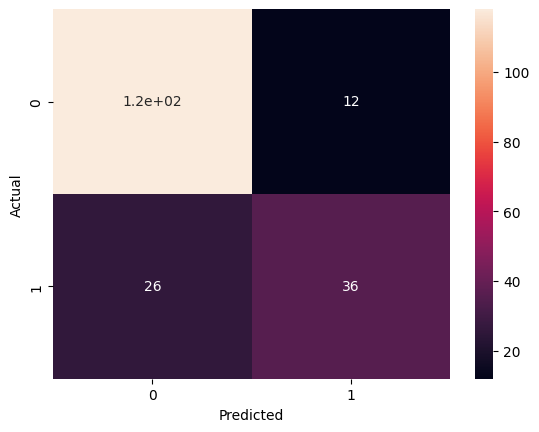

In [14]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)